<a href="https://colab.research.google.com/github/shirohigexe/practicas_HO_ML/blob/main/MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn.datasets import fetch_openml
mnist  = fetch_openml('mnist_784', as_frame=False)


In [ ]:
print(mnist.DESCR)

**Author**: Yann LeCun, Corinna Cortes, Christopher J.C. Burges  
**Source**: [MNIST Website](http://yann.lecun.com/exdb/mnist/) - Date unknown  
**Please cite**:  

The MNIST database of handwritten digits with 784 features, raw data available at: http://yann.lecun.com/exdb/mnist/. It can be split in a training set of the first 60,000 examples, and a test set of 10,000 examples  

It is a subset of a larger set available from NIST. The digits have been size-normalized and centered in a fixed-size image. It is a good database for people who want to try learning techniques and pattern recognition methods on real-world data while spending minimal efforts on preprocessing and formatting. The original black and white (bilevel) images from NIST were size normalized to fit in a 20x20 pixel box while preserving their aspect ratio. The resulting images contain grey levels as a result of the anti-aliasing technique used by the normalization algorithm. the images were centered in a 28x28 image b

In [ ]:
X,y = mnist.data, mnist.target
X


array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [ ]:
y

array(['5', '0', '4', ..., '4', '5', '6'], dtype=object)

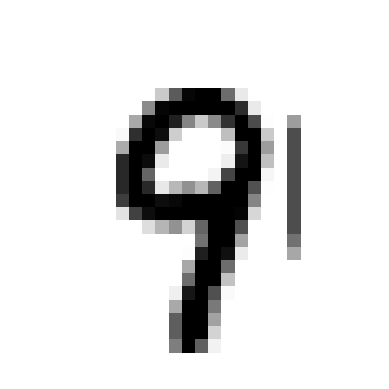

In [ ]:
import matplotlib.pyplot as plt
import random

def plot_digit(image_data):
  image = image_data.reshape(28,28) #redimencionar
  plt.imshow(image, cmap='binary')
  plt.axis('off')
  plt.show()

random = random.randint(0,69999)
some_digit = X[random]
plot_digit(some_digit)

In [ ]:
y[random]

'9'

In [ ]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

esto es posible porque el dataset ya viene sep'arado y listo, debido a que es un dataset de juguete

# entrenando un clasificador binario
clasificaremos algo basico, suponiendo el nueve, de manera que será la clase 'nueve' y la clase 'no nueve'

In [ ]:
y_train_9 = (y_train == '9') # True para todos los nueves, falso para el resto de digitos
y_test_9 = (y_test == '9')

In [ ]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_9)


SGDClassifier(random_state=42)

In [ ]:
sgd_clf.predict([some_digit])

array([ True])

## Medidas de rendimiento

evaluar un clasificador es a menudo sigtnificativanebtre más complicado que evaluar un regresor

### Medidas de exactitud usando cross-validation

In [ ]:
from sklearn.model_selection import cross_val_score

cross_val_score(sgd_clf, X_train, y_train_9, cv=3, scoring="accuracy")

array([0.9456 , 0.95195, 0.9509 ])

antes de sobre excaltar esors resultados, veamos un clasificador Dummy, que calsifica cada imagen en la más frecuente, que en este caso son los 'no-nueve'

In [ ]:
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier()
dummy_clf.fit(X_train, y_train_9)
print(any(dummy_clf.predict(X_train)))

False


In [ ]:
cross_val_score(dummy_clf, X_train, y_train_9, cv=3, scoring="accuracy")

array([0.90085, 0.90085, 0.90085])

ese 90% de exactitud es simplemente porque solo el 10% de las imagenes son 9, por lo tanto, hay un 90% de probabilidades de que aciertes a que un numero no es un 9

### Matriz de confusion

In [ ]:
from sklearn.model_selection import cross_val_predict

y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_9, cv=3)

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_train_9, y_train_pred)
cm

array([[52715,  1336],
       [ 1695,  4254]])

In [ ]:
y_train_perfect_predictions = y_train_9 #suponiendo la perfeccion
confusion_matrix(y_train_9, y_train_perfect_predictions)

array([[54051,     0],
       [    0,  5949]])

Para medir la precision usando la matriz de confusion usamos:
* precision = TP/(TP + FP)
* recall = TP/(TP + FN)
* F1 = 2 x [(precision x recall) / (precision + recall)]

In [ ]:
from sklearn.metrics import precision_score, recall_score

precision_score(y_train_9, y_train_pred)

# claro que se puede hacer de manera manual gracias a numpy
# cm[1, 1] / (cm[0, 1] + cm[1, 1])

0.7610017889087657

In [ ]:
recall_score(y_train_9, y_train_pred)

0.7150781643973777

In [ ]:
from sklearn.metrics import f1_score

f1_score(y_train_9, y_train_pred)

0.737325591472398

ahora veremos un trade-off entre precision y recall

In [ ]:
y_scores = sgd_clf.decision_function([some_digit])
y_scores

array([886.46486837])

In [ ]:
threshold = 3000
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred

array([False])

para decidir el umbral una opcion es usar la siguiente funcion para conseguir puntajes de todas las instancias el el conjunto de entrenamiento

In [ ]:
y_scores = cross_val_predict(sgd_clf, X_train, y_train_9, cv=3,
                             method="decision_function")

In [ ]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_train_9, y_scores)

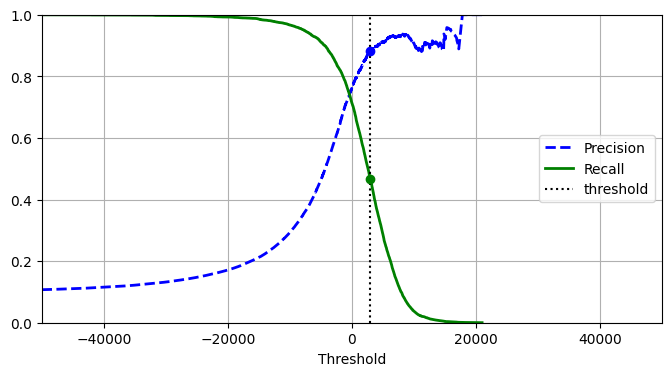

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
plt.vlines(threshold, 0, 1.0, "k", "dotted", label="threshold")

idx = (thresholds >= threshold).argmax()
plt.plot(thresholds[idx], precisions[idx], "bo")
plt.plot(thresholds[idx], recalls[idx], "go")
plt.axis([-50000, 50000, 0, 1])
plt.grid()
plt.xlabel("Threshold")
plt.legend(loc="center right")

plt.show()

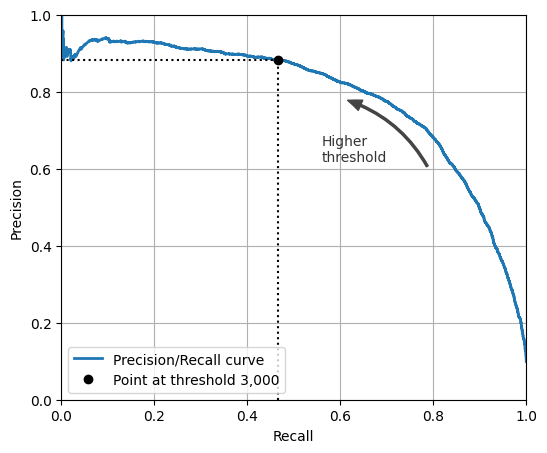

In [ ]:
import matplotlib.patches as patches  # extra code – for the curved arrow

plt.figure(figsize=(6, 5))  # extra code – not needed, just formatting

plt.plot(recalls, precisions, linewidth=2, label="Precision/Recall curve")

# extra code – just beautifies Figure 3–6
plt.plot([recalls[idx], recalls[idx]], [0., precisions[idx]], "k:")
plt.plot([0.0, recalls[idx]], [precisions[idx], precisions[idx]], "k:")
plt.plot([recalls[idx]], [precisions[idx]], "ko",
         label="Point at threshold 3,000")
plt.gca().add_patch(patches.FancyArrowPatch(
    (0.79, 0.60), (0.61, 0.78),
    connectionstyle="arc3,rad=.2",
    arrowstyle="Simple, tail_width=1.5, head_width=8, head_length=10",
    color="#444444"))
plt.text(0.56, 0.62, "Higher\nthreshold", color="#333333")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.axis([0, 1, 0, 1])
plt.grid()
plt.legend(loc="lower left")

plt.show()

a continuacion, un ejemplo si quisieramos el valor excato para tener una precision mayor al 90% y como afecta al recall

In [ ]:
idx_for_90_precision = (precisions >= 0.90).argmax()
threshold_for_90_precision = thresholds[idx_for_90_precision]
threshold_for_90_precision

np.float64(4255.5613542876035)

In [ ]:
y_train_pred_90 = (y_scores >= threshold_for_90_precision)

In [ ]:
precision_score(y_train_9, y_train_pred_90)

0.9001728608470182

In [ ]:
recall_at_90_precision = recall_score(y_train_9, y_train_pred_90)
recall_at_90_precision

0.3501428811564969

usemos la curva ROC para ver vomo funciona anuestro modelo

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_train_9, y_scores)

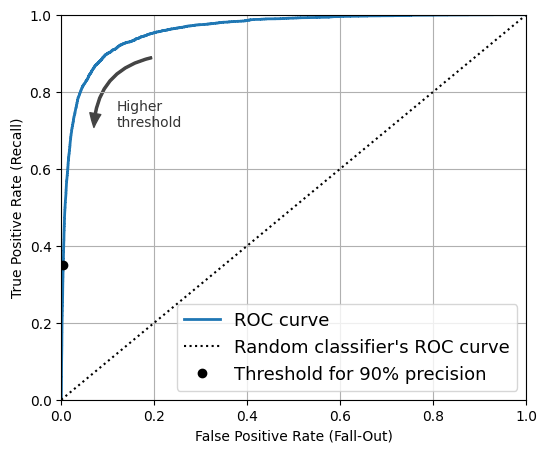

In [ ]:
idx_for_threshold_at_90 = (thresholds <= threshold_for_90_precision).argmax()
tpr_90, fpr_90 = tpr[idx_for_threshold_at_90], fpr[idx_for_threshold_at_90]

plt.figure(figsize=(6, 5))  # extra code – not needed, just formatting
plt.plot(fpr, tpr, linewidth=2, label="ROC curve")
plt.plot([0, 1], [0, 1], 'k:', label="Random classifier's ROC curve")
plt.plot([fpr_90], [tpr_90], "ko", label="Threshold for 90% precision")

plt.gca().add_patch(patches.FancyArrowPatch(
    (0.20, 0.89), (0.07, 0.70),
    connectionstyle="arc3,rad=.4",
    arrowstyle="Simple, tail_width=1.5, head_width=8, head_length=10",
    color="#444444"))
plt.text(0.12, 0.71, "Higher\nthreshold", color="#333333")
plt.xlabel('False Positive Rate (Fall-Out)')
plt.ylabel('True Positive Rate (Recall)')
plt.grid()
plt.axis([0, 1, 0, 1])
plt.legend(loc="lower right", fontsize=13)

plt.show()

In [ ]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_train_9, y_scores)

np.float64(0.96114559368217)

# Clasificacion multiclase


In [ ]:
from sklearn.svm import SVC

svm_clf = SVC(random_state=42)
svm_clf.fit(X_train[:2000], y_train[:2000])  # y_train, not y_train_9

SVC(random_state=42)

Como escogimos el modelo SVC, el sistema escoge automaticamente el metoo OvO, aunque pueda parecer raro, es mucho más eficiente ya que trabajara con una fraccion de los datos, a diferencia de OvR

In [ ]:
svm_clf.predict([some_digit])

array(['3'], dtype=object)

ya que estamos usando OvO, llamemos la funcion desicion_function() para ver los puntajes por instancia

In [ ]:
some_digit_scores = svm_clf.decision_function([some_digit])
some_digit_scores.round(2)

array([[ 7.13, -0.28,  3.85,  9.3 ,  0.74,  8.29,  1.76,  2.74,  4.85,
         5.98]])

vemos que el puntaje más alto es 9.3 que como veremos a continuacion corresponde a la clase del digito random

In [ ]:
class_id = some_digit_scores.argmax()
class_id

np.int64(3)

In [ ]:
svm_clf.classes_

array(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'], dtype=object)

In [ ]:
svm_clf.classes_[class_id]

'3'

supongamos que quisieramos obligar a usar el metodo OvR

In [ ]:
from sklearn.multiclass import OneVsRestClassifier

ovr_clf = OneVsRestClassifier(SVC(random_state=42))
ovr_clf.fit(X_train[:2000], y_train[:2000])

OneVsRestClassifier(estimator=SVC(random_state=42))

In [ ]:
ovr_clf.predict([some_digit])

array(['3'], dtype='<U1')

Ahora veamos el ejemplo con SGD

In [ ]:
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train)
sgd_clf.predict([some_digit])

array(['3'], dtype='<U1')

Como usó OvR tras bambalinas, uso 10 modelos para clasificar el número

In [ ]:
sgd_clf.decision_function([some_digit]).round()

array([[-24194., -26421., -19193.,   4189., -18536.,   -450., -17879.,
        -35828.,  -5917., -25119.]])

In [ ]:
cross_val_score(sgd_clf, X_train, y_train, cv=3, scoring="accuracy")

array([0.87365, 0.85835, 0.8689 ])

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.astype("float64"))
cross_val_score(sgd_clf, X_train_scaled, y_train, cv=3, scoring="accuracy")

array([0.8983, 0.891 , 0.9018])

# Analisis de Error

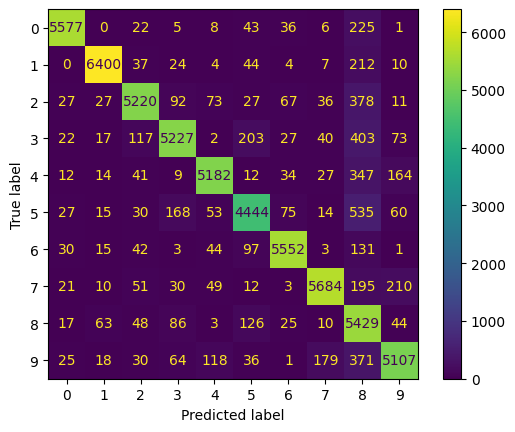

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

y_train_pred = cross_val_predict(sgd_clf, X_train_scaled, y_train, cv=3)
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred)
plt.show()

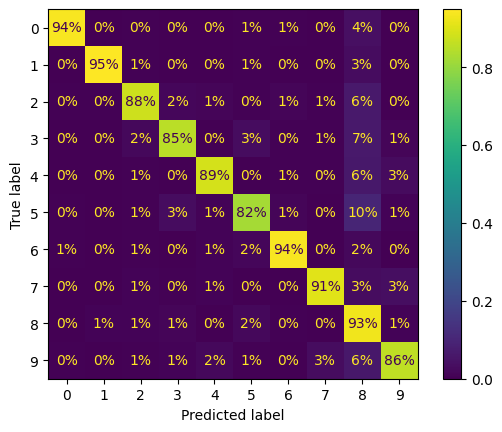

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred,
                                        normalize="true", values_format=".0%")
plt.show()

como podemos ver, el sistema confunde algtunos numero con 8s, esto, se vé aun más como sigue

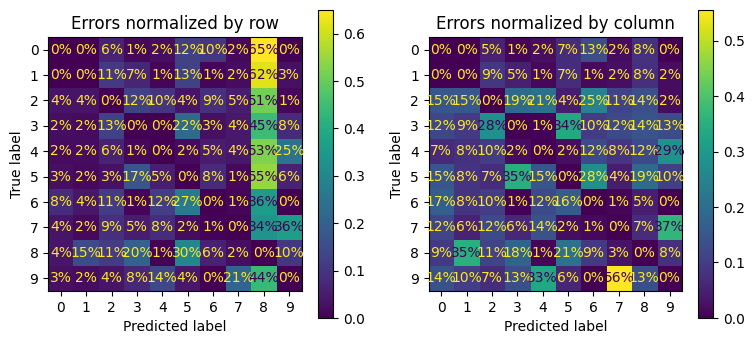

In [ ]:
sample_weight = (y_train_pred != y_train)
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(9, 4))
plt.rc('font', size=10)
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, ax=axs[0],
                                        sample_weight=sample_weight,
                                        normalize="true", values_format=".0%")
axs[0].set_title("Errors normalized by row")
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, ax=axs[1],
                                        sample_weight=sample_weight,
                                        normalize="pred", values_format=".0%")
axs[1].set_title("Errors normalized by column")

plt.show()

estos porcentajes no se pueden confundir, el 36% de la fila #7 columna #9 no quiere decir que el 36% de 7s fueron clasificados como 9s

In [ ]:
cl_a, cl_b = '3', '5'
X_aa = X_train[(y_train == cl_a) & (y_train_pred == cl_a)]
X_ab = X_train[(y_train == cl_a) & (y_train_pred == cl_b)]
X_ba = X_train[(y_train == cl_b) & (y_train_pred == cl_a)]
X_bb = X_train[(y_train == cl_b) & (y_train_pred == cl_b)]

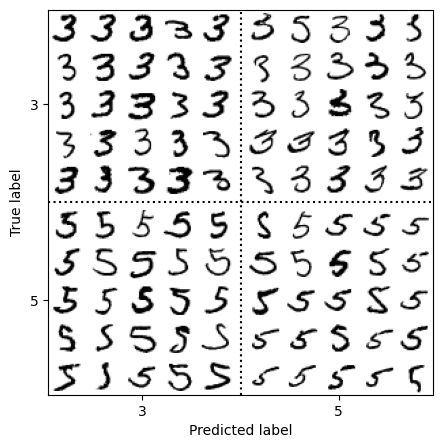

In [ ]:
size = 5
pad = 0.2
plt.figure(figsize=(size, size))
for images, (label_col, label_row) in [(X_ba, (0, 0)), (X_bb, (1, 0)),
                                       (X_aa, (0, 1)), (X_ab, (1, 1))]:
    for idx, image_data in enumerate(images[:size*size]):
        x = idx % size + label_col * (size + pad)
        y = idx // size + label_row * (size + pad)
        plt.imshow(image_data.reshape(28, 28), cmap="binary",
                   extent=(x, x + 1, y, y + 1))
plt.xticks([size / 2, size + pad + size / 2], [str(cl_a), str(cl_b)])
plt.yticks([size / 2, size + pad + size / 2], [str(cl_b), str(cl_a)])
plt.plot([size + pad / 2, size + pad / 2], [0, 2 * size + pad], "k:")
plt.plot([0, 2 * size + pad], [size + pad / 2, size + pad / 2], "k:")
plt.axis([0, 2 * size + pad, 0, 2 * size + pad])
plt.xlabel("Predicted label")
plt.ylabel("True label")

plt.show()

como vemos, entender los errores en la clasificacion nos dá un panorama de la situacino, como se ve en el ejemplo, es posible tener errores que para el ser humano son complpicados

# Ejercicios

## 1) Un clasificador MNIST con más del 97% de precisión

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train, y_train)
baseline_accuracy = cross_val_score(knn_clf, X_train, y_train, cv=3, scoring="accuracy")
baseline_accuracy

array([0.9676 , 0.9671 , 0.96755])

In [ ]:
baseline_accuracy_1 = knn_clf.score(X_train, y_train)
baseline_accuracy_1

0.9819166666666667

aunque ya se cumplio, hare la recomendacion del libro de usar grid search

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = [{'weights': ["uniform", "distance"], 'n_neighbors': [3, 4, 5, 6]}]
knn_clf = KNeighborsClassifier()
grid_search = GridSearchCV(knn_clf, param_grid, cv = 5)
grid_search.fit(X_train[:10_000], y_train[:10_000])

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid=[{'n_neighbors': [3, 4, 5, 6],
                          'weights': ['uniform', 'distance']}])

In [ ]:
grid_search.best_params_

{'n_neighbors': 4, 'weights': 'distance'}

In [ ]:
grid_search.best_score_

np.float64(0.9441999999999998)

In [ ]:
grid_search.best_estimator_.fit(X_train, y_train)
tuned_accuracy = grid_search.score(X_test, y_test)
tuned_accuracy

0.9714